# Previsione dei Rendimenti del Bitcoin

**Realizzato da:** Tverdohleb Egor (Matricola: 0001114726)  
Email istituzionale: egor.tverdohleb@studio.unibo.it

## 1. Caricamento Librerie

Per prima cosa carichiamo le librerie fondamentali per effettuare le operazioni di manipolazione, analisi e visualizzazione grafica dei dati. 
 - *pandas*: Per il caricamento, la pulizia e la manipolazione di strutture dati tabulari
 - *numpy*: Per supportare il calcolo matematico e vettoriale su array a N dimensioni
 - *yfinance*: Per estrapolare in tempo reale i dati finanziari storici direttamente dalle API di Yahoo Finance.
 - *matplotlib.pyplot*: Per la generazione di grafici e report visivi
 - *sklearn*: Gestisce l'intero flusso di machine learning, dalla standardizzazione dei dati alla configurazione, addestramento e valutazione dei modelli (lineari, non lineari e Grid Search).
 - *seaborn*: Realizza la visualizzazione grafica avanzata delle matrici di correlazione tramite heatmap.

Abilitiamo inoltre l'inserimento dei grafici direttamente all'interno del notebook tramite `%matplotlib inline`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, make_scorer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

%matplotlib inline

## 2. Caricamento e Analisi dei Dati

Procediamo all'estrazione dei dati storici relativi alla criptovaluta di cui vogliamo predirre il costo, il **Bitcoin**. Estraiamo un orizzonte temporale fisso di 5 anni (dal 1° giugno 2021 al 1° giugno 2026), raccogliendo un volume di dati giornalieri sufficientemente ampio (oltre 1800 istanze). Le date sono fissate esplicitamente, anziché usare una finestra mobile, per garantire la **piena riproducibilità** dei risultati a ogni esecuzione.

### Significato delle colonne native di Yahoo Finance:
- `Open`: Prezzo di apertura della giornata finanziaria (espressa in USD)
- `High`: Prezzo massimo registrato durante la giornata
- `Low`: Prezzo minimo registrato durante la giornata
- `Close`: Prezzo di chiusura formale della giornata
- `Volume`: Volume monetario totale degli scambi registrati nelle 24 ore.
- `Dividends`: Dividendi distribuiti (tipico delle azioni, non applicabile alle crypto).
- `Stock Splits`: Frazionamenti azionari (non applicabile alle crypto).

In [2]:
DATA_START = "2021-06-01"
DATA_END   = "2026-06-01"

btc = yf.Ticker("BTC-USD")
df = btc.history(start=DATA_START, end=DATA_END)
display(df.tail())

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-05-27 00:00:00+00:00,75825.304688,76014.296875,74136.500000,74344.703125,33802172927,0.0,0.0
2026-05-28 00:00:00+00:00,74339.570312,74460.125000,72493.414062,73536.554688,40148145327,0.0,0.0
2026-05-29 00:00:00+00:00,73537.031250,74218.562500,72435.625000,73372.523438,34457929250,0.0,0.0
2026-05-30 00:00:00+00:00,73370.851562,74020.757812,73125.234375,73754.835938,19563589191,0.0,0.0
2026-05-31 00:00:00+00:00,73753.750000,74153.500000,73315.015625,73579.687500,17445435650,0.0,0.0


### 2.1 Analisi Strutturale ed Eliminazione Ridondanze

Come evidenziato dall'anteprima del dataset, le colonne `Dividends` e `Stock Splits` presentano esclusivamente valori pari a `0.0` o `NaN`. Questo comportamento riflette l'asset class di riferimento: a differenza dei titoli azionari tradizionali, le criptovalute non distribuiscono dividendi societari né subiscono frazionamenti di capitale.

Al fine di ottimizzare lo spazio occupato in memoria e rimuovere feature prive di utilità, procediamo alla loro rimozione.

In [3]:
df.drop(columns=["Dividends", "Stock Splits"], inplace=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1826 entries, 2021-06-01 00:00:00+00:00 to 2026-05-31 00:00:00+00:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    1826 non-null   float64
 1   High    1826 non-null   float64
 2   Low     1826 non-null   float64
 3   Close   1826 non-null   float64
 4   Volume  1826 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 85.6 KB


### 2.2 Semplificazione dei dati

Una caratteristica fondamentale delle criptovalute rispetto ai mercati tradizionali è l'operatività continua: i mercati crypto scambiano senza interruzioni.

Per verificare empiricamente l'efficienza informativa e la continuità dei prezzi, andiamo a calcolare la discrepanza percentuale tra il prezzo di chiusura (`Close`) di un giorno e il prezzo di apertura (`Open`) del giorno successivo. Se il mercato è perfettamente continuo e privo di interruzioni, questa differenza dovrebbe essere prossima allo zero.

In [4]:
df['Open_Tomorrow'] = df['Open'].shift(-1)
df['Gap_Percentuale'] = ((df['Open_Tomorrow'] - df['Close']) / df['Close']) * 100

print(df['Gap_Percentuale'].describe())

count    1825.000000
mean        0.003607
std         0.133101
min        -0.817254
25%        -0.007260
50%        -0.000283
75%         0.005499
max         3.791078
Name: Gap_Percentuale, dtype: float64


Come previsto la differenza media è virtualmente nulla, possiamo quindi rinominare la colonna Close in Price per ridurre la ridondanza. Manteniamo invece la colonna `Open`: pur essendo ridondante ai fini della previsione del giorno successivo, ci servirà più avanti per analizzare la **variazione intraday** (la differenza tra apertura e chiusura della stessa giornata).

In [5]:
df = df.rename(columns={'Close': 'Price'})
df.drop(columns=['Open_Tomorrow', 'Gap_Percentuale'], inplace=True)

### 2.3 Integrazione dei Dati di altre cryptovalute (Ethereum e Solana)

Per arricchire il contesto predittivo dell'algoritmo, andiamo a implementare un'analisi multi-asset. Il mercato delle criptovalute è fortemente interconnesso e dominato da trend globali. 

Scarichiamo i dati storici di altre due monete virtuali **Ethereum (ETH-USD)** e **Solana (SOL-USD)**, allineandole sul dataset principale.

In [6]:
eth = yf.Ticker("ETH-USD")
df_eth = eth.history(start=DATA_START, end=DATA_END)[['Close']].rename(columns={'Close': 'Price_ETH'})

sol = yf.Ticker("SOL-USD")
df_sol = sol.history(start=DATA_START, end=DATA_END)[['Close']].rename(columns={'Close': 'Price_SOL'})

df = df.join(df_eth, how='left')
df = df.join(df_sol, how='left')

df.head()

,Open,High,Low,Price,Volume,Price_ETH,Price_SOL
Date,,,,,,,
2021-06-01 00:00:00+00:00,37293.792969,37896.734375,35787.085938,36684.925781,34639423297,2633.518311,30.985260
2021-06-02 00:00:00+00:00,36699.921875,38231.339844,35966.308594,37575.179688,33070867190,2706.125000,33.956318
2021-06-03 00:00:00+00:00,37599.410156,39478.953125,37243.972656,39208.765625,35460750427,2855.126465,39.470905
2021-06-04 00:00:00+00:00,39242.484375,39242.484375,35717.722656,36894.406250,41831090187,2688.195068,37.415070
2021-06-05 00:00:00+00:00,36880.156250,37917.714844,34900.414062,35551.957031,35959473399,2630.576904,39.585400


Andiamo a verificare la su detta correlazione rappresentandola graficamente

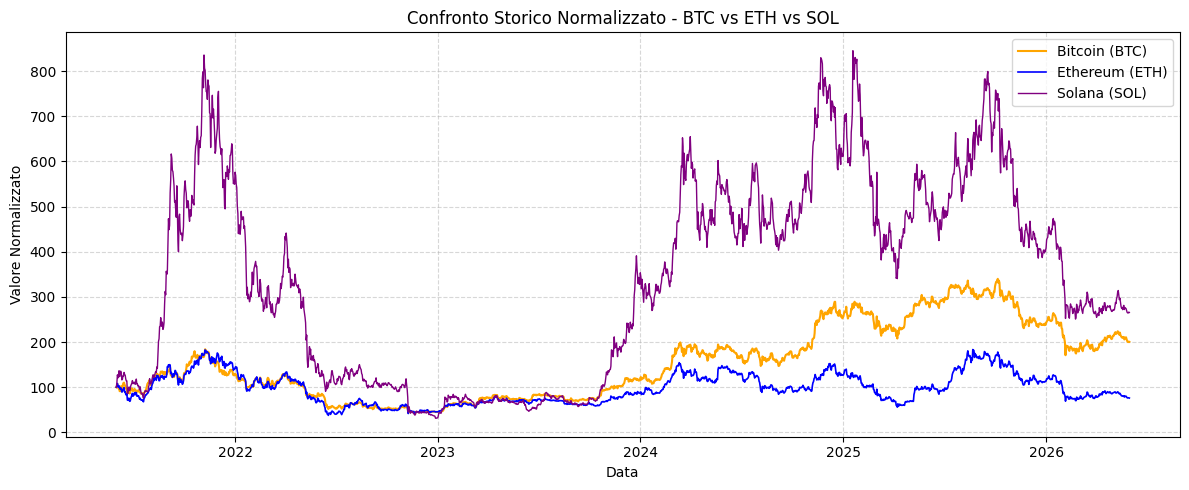

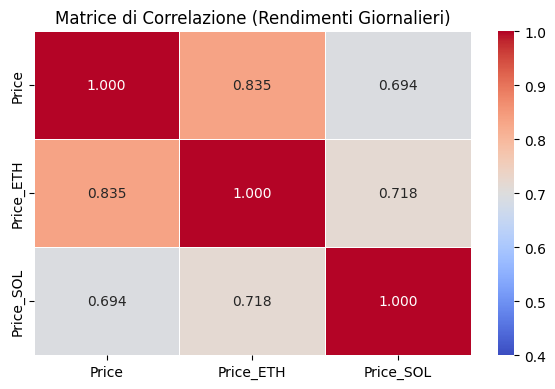

In [7]:
crypto_cols = ['Price', 'Price_ETH', 'Price_SOL']
df_crypto_prices = df[crypto_cols]

df_norm = (df_crypto_prices / df_crypto_prices.iloc[0]) * 100

plt.figure(figsize=(12, 5))
plt.plot(df_norm.index, df_norm['Price'], label='Bitcoin (BTC)', color='orange', linewidth=1.5)
plt.plot(df_norm.index, df_norm['Price_ETH'], label='Ethereum (ETH)', color='blue', linewidth=1.2)
plt.plot(df_norm.index, df_norm['Price_SOL'], label='Solana (SOL)', color='purple', linewidth=1)

plt.title('Confronto Storico Normalizzato - BTC vs ETH vs SOL')
plt.xlabel('Data')
plt.ylabel('Valore Normalizzato')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

returns_df = df_crypto_prices.pct_change().dropna()

corr_matrix = returns_df.corr(method='pearson')

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0.4, vmax=1, fmt=".3f", linewidths=0.5)
plt.title('Matrice di Correlazione (Rendimenti Giornalieri)')
plt.tight_layout()
plt.show()

Il grafico normalizzato e la matrice di correlazione indicano chiaramente una fortissima correlazione dei dati. Questo potrebbe rivelarsi problematico agli scopi di questo progetto, se infatti i tre mercati si muovono univocamente non possiamo usarne uno per prevedere gli altri. Andiamo a studiare la correlazione tra Solana ed Ethereum al giorno successivo di Bitcoin per vedere se essi sono dati significativi

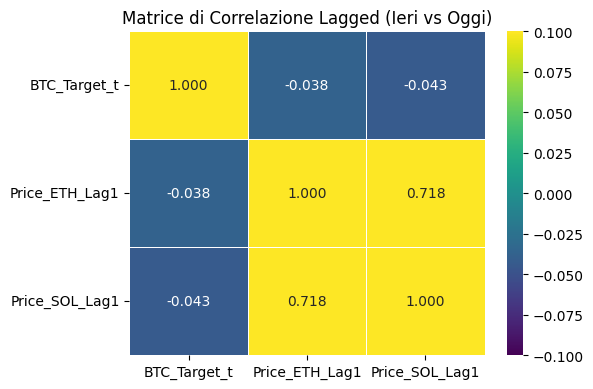

In [8]:
df_crypto_prices = df[['Price', 'Price_ETH', 'Price_SOL']]
returns_df = df_crypto_prices.pct_change().dropna()

df_lagged = pd.DataFrame()
df_lagged['BTC_Target_t'] = returns_df['Price']

df_lagged['Price_ETH_Lag1'] = returns_df['Price_ETH'].shift(1)
df_lagged['Price_SOL_Lag1'] = returns_df['Price_SOL'].shift(1)

df_lagged = df_lagged.dropna()

lagged_corr = df_lagged.corr(method='pearson')

plt.figure(figsize=(6, 4))
sns.heatmap(lagged_corr, annot=True, cmap='viridis', vmin=-0.1, vmax=0.1, fmt=".3f", linewidths=0.5)
plt.title('Matrice di Correlazione Lagged (Ieri vs Oggi)')
plt.tight_layout()
plt.show()

Purtroppo quindi i dati aggiunti si sono rivelati poco informativi allo scopo di predire il prezzo di bitcoin. Procediamo dunque a rimuovere i dati precedentemente aggiunti

In [9]:
df.drop(columns=['Price_ETH', 'Price_SOL'], inplace=True)

### 2.4 Aggiunta Feature: Calcolo della Volatilità

La volatilità è una misura statistica fondamentale nei mercati finanziari, indicando il livello di incertezza e rischio. 
Andiamo a calcolare la volatilità storica su una finestra mobile di 30 giorni. Utilizzeremo la formula del *range normalizzato di oscillazione giornaliera* (differenza percentuale massima tra High e Low rispetto al prezzo di chiusura), che esprime l'escursione dei prezzi indipendentemente dal loro valore assoluto in dollari.

In [10]:
range_btc = ((df['High'] - df['Low']) / df['Price']) * 100
df['Volatility_30d'] = range_btc.rolling(window=30).mean()

df.tail()

,Open,High,Low,Price,Volume,Volatility_30d
Date,,,,,,
2026-05-27 00:00:00+00:00,75825.304688,76014.296875,74136.500000,74344.703125,33802172927,2.453972
2026-05-28 00:00:00+00:00,74339.570312,74460.125000,72493.414062,73536.554688,40148145327,2.464088
2026-05-29 00:00:00+00:00,73537.031250,74218.562500,72435.625000,73372.523438,34457929250,2.416357
2026-05-30 00:00:00+00:00,73370.851562,74020.757812,73125.234375,73754.835938,19563589191,2.400368
2026-05-31 00:00:00+00:00,73753.750000,74153.500000,73315.015625,73579.687500,17445435650,2.327484


### 2.5 Aggiunta feature: I Costi Energetici Globali

Per tentare di trovare un modello effettivamente predittivo cerchiamo di integrare dinamiche macroeconomiche legate al costo di estrazione della criptovaluta (*Proof of Work*), procediamo quindi integrando un indicatore energetico.

Utilizziamo i Futures del **Gas Naturale (NG=F)** come proxy per determinare l'andamento del costo dell'energia elettrica a livello globale. Risolviamo preventivamente le discrepanze di fuso orario ed effettuiamo un'operazione di *Forward Fill* per coprire le sessioni di chiusura del weekend tipiche dei mercati delle commodity tradizionali

In [11]:
energia = yf.Ticker("NG=F")
df_energia = energia.history(start=DATA_START, end=DATA_END)

df.index = df.index.tz_localize(None)
df_energia.index = df_energia.index.tz_localize(None)

range_energia = ((df_energia['High'] - df_energia['Low']) / df_energia['Close']) * 100
df_energia['Volatility_Energy_30d'] = range_energia.rolling(window=30).mean()
df_energia = df_energia[['Close', 'Volatility_Energy_30d']].rename(columns={'Close': 'Price_Energy'})

columns_to_drop = [col for col in df_energia.columns if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)
    
df = df.join(df_energia, how='left')

df['Price_Energy'] = df['Price_Energy'].ffill()
df['Volatility_Energy_30d'] = df['Volatility_Energy_30d'].ffill()

df = df.dropna()

display(df.head())

,Open,High,Low,Price,Volume,Volatility_30d,Price_Energy,Volatility_Energy_30d
Date,,,,,,,,
2021-07-13,33125.468750,33327.101562,32261.419922,32702.025391,19120856669,6.278232,3.696,3.640051
2021-07-14,32723.845703,33061.398438,31639.125000,32822.347656,21376531210,6.238589,3.660,3.614385
2021-07-15,32827.875000,33159.640625,31175.708984,31780.730469,21300524237,6.307604,3.614,3.606710
2021-07-16,31841.550781,32218.406250,31100.673828,31421.539062,23699476918,6.222708,3.674,3.637491
2021-07-17,31397.308594,31935.945312,31223.990234,31533.068359,18895018942,6.116294,3.674,3.637491


## 3. Preparazione del Dataset

### 3.1 Calcolo dei Rendimenti e del Momentum Temporale

Per migliorare la capacità predittiva su un mercato che ha subito enormi variazioni di prezzo nel tempo, è fondamentale trasformare il dataset per lavorare su rendimenti percentuali. Questa operazione trasforma i prezzi grezzi in una serie storica stazionaria, requisito essenziale per garantire il corretto funzionamento dei modelli lineari.

Calcoliamo le variazioni percentuali a 1, 3 e 7 giorni per tutti gli asset. Questo blocco di variabili tentano di dare una quantificazione al concetto di Momentum, ossia la tendenza dei mercati a seguire una direzione univoca per un breve lasso di tempo.

Per coerenza con lo stesso principio di stazionarietà, non utilizziamo il `Volume` in valore assoluto ma il volume relativo, ossia il rapporto tra il volume del giorno e la sua media mobile a 30 giorni.

In [12]:
df['BTC_Return_1d'] = df['Price'].pct_change(1) * 100
df['BTC_Return_3d'] = df['Price'].pct_change(3) * 100
df['BTC_Return_7d'] = df['Price'].pct_change(7) * 100

df['Energy_Return_1d'] = df['Price_Energy'].pct_change(1) * 100
df['Energy_Return_3d'] = df['Price_Energy'].pct_change(3) * 100
df['Energy_Return_7d'] = df['Price_Energy'].pct_change(7) * 100

df['Volume_Rel_30d'] = df['Volume'] / df['Volume'].rolling(window=30).mean()

df = df.dropna()
display(df.head())

,Open,High,Low,Price,Volume,Volatility_30d,Price_Energy,Volatility_Energy_30d,BTC_Return_1d,BTC_Return_3d,BTC_Return_7d,Energy_Return_1d,Energy_Return_3d,Energy_Return_7d,Volume_Rel_30d
Date,,,,,,,,,,,,,,,
2021-08-11,45599.703125,46735.632812,45351.710938,45593.636719,34319709073,5.440984,4.059,3.713427,0.018878,4.099536,14.708176,-0.733681,-1.956518,-2.380952,1.210357
2021-08-12,45576.878906,46228.910156,43861.445312,44428.289062,33723620826,5.509983,3.933,3.663184,-2.555944,-4.177928,8.707544,-3.104211,-3.128075,-4.999995,1.169263
2021-08-13,44439.691406,47831.976562,44282.417969,47793.320312,31744259539,5.613104,3.861,3.598045,7.574073,4.844329,11.623604,-1.830664,-5.575939,-6.739126,1.087602
2021-08-14,47810.687500,48098.683594,46177.632812,47096.945312,31211354442,5.540983,3.861,3.598045,-1.457055,3.297189,5.703286,0.000000,-4.878048,-6.739126,1.057376
2021-08-15,47096.667969,47357.105469,45579.589844,47047.003906,30988958446,5.548348,3.861,3.598045,-0.106040,5.894251,7.417868,0.000000,-1.830664,-6.739126,1.041270


### 3.2 Generazione della Variabile Target con Spostamento Temporale

Il nostro obiettivo è usare le informazioni disponibili alla chiusura di oggi per prevedere il rendimento del Bitcoin di domani. Questo disallineamento temporale controllato costringe l'algoritmo ad effettuare una previsione sul giorno successivo.

In [13]:
df['Target_BTC_Return_Tomorrow'] = df['BTC_Return_1d'].shift(-1)

df = df.dropna()

colonne_da_escludere = ['Target_BTC_Return_Tomorrow', 'High', 'Low', 'Price', 'Price_Energy', 'Open', 'Volume']
X = df.drop(columns=colonne_da_escludere)
y = df['Target_BTC_Return_Tomorrow']

print(f"Formato della matrice delle Feature (X): {X.shape} (Righe, Variabili Predittive)")
print(f"Formato del Target (y): {y.shape} (Risposte corrette)")
print()
print("Le variabili che l'IA userà per predire il rendimento di domani sono:")
print(list(X.columns))

Formato della matrice delle Feature (X): (1754, 9) (Righe, Variabili Predittive)
Formato del Target (y): (1754,) (Risposte corrette)

Le variabili che l'IA userà per predire il rendimento di domani sono:
['Volatility_30d', 'Volatility_Energy_30d', 'BTC_Return_1d', 'BTC_Return_3d', 'BTC_Return_7d', 'Energy_Return_1d', 'Energy_Return_3d', 'Energy_Return_7d', 'Volume_Rel_30d']


### 3.3 Suddivisione in Training Set e Test Set

Per convalidare i modelli predittivi effettuiamo un taglio netto impostando una proporzione del **70% per il Training Set** e il restante **30% per il Test Set**

In [14]:
split_index = int(len(df) * 0.70)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Istanze totali nel dataset: {len(df)}")
print(f"Training Set (70%): {X_train.shape[0]} giorni (da {X_train.index[0].strftime('%Y-%m-%d')} a {X_train.index[-1].strftime('%Y-%m-%d')})")
print(f"Test Set (30%):     {X_test.shape[0]} giorni (da {X_test.index[0].strftime('%Y-%m-%d')} a {X_test.index[-1].strftime('%Y-%m-%d')})")

Istanze totali nel dataset: 1754
Training Set (70%): 1227 giorni (da 2021-08-11 a 2024-12-19)
Test Set (30%):     527 giorni (da 2024-12-20 a 2026-05-30)


## 4. Addestramento e Validazione dei Modelli Baseline

Andiamo ad addestrare e validare due modelli di natura differente, calcolando le seguenti misure di performance: il **Mean Squared Error (MSE)**, il **Root Mean Squared Error (RMSE)** espresso nella scala percentuale e il coefficiente di determinazione **$R^2$**.

1. **Regressione Lineare (Modello Lineare):**
2. **Random Forest Regressor (Modello Non Lineare):**

In [15]:
lr_model = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

def calcola_metriche(y_reale, y_predette, nome_modello):
    mse = mean_squared_error(y_reale, y_predette)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_reale, y_predette)
    
    print(f"Performance Modello: {nome_modello}")
    print(f"Mean Squared Error (MSE):  {mse:.5f}")
    print(f"Root MSE (RMSE):           {rmse:.4f}%")
    print(f"Coefficiente R²:           {r2:.5f}")
    print("-" * 40)
    return mse, rmse, r2

lr_mse, lr_rmse, lr_r2 = calcola_metriche(y_test, lr_preds, "Linear Regression")
rf_mse, rf_rmse, rf_r2 = calcola_metriche(y_test, rf_preds, "Random Forest")

Performance Modello: Linear Regression
Mean Squared Error (MSE):  5.41738
Root MSE (RMSE):           2.3275%
Coefficiente R²:           -0.00787
----------------------------------------
Performance Modello: Random Forest
Mean Squared Error (MSE):  5.99691
Root MSE (RMSE):           2.4489%
Coefficiente R²:           -0.11569
----------------------------------------


### 4.1 Discussione dei Risultati

Il test empirico dimostra che i modelli sviluppati non possiedono alcun reale potere predittivo. Questo risultato era statisticamente atteso considerando l'ipotesi di efficienza del mercato e il fenomeno del Random Walk. Nella teoria dei mercati efficienti in forma semi-forte, i rendimenti giornalieri degli asset speculativi liquidi si comportano come puro rumore bianco nel brevissimo termine. Il valore di $R^2$ sotto allo zero indica l'assoluta assenza di pattern lineari o non lineari interni facilmente sfruttabili.

### 4.2 Analisi della Rilevanza delle Variabili

Andiamo ad analizzare la struttura interna del modello per estrarre l'importanza relativa delle feature. Questo ci permette di mappare quali indizi l'algoritmo reputi più utili per approssimare il rendimento futuro del Bitcoin.

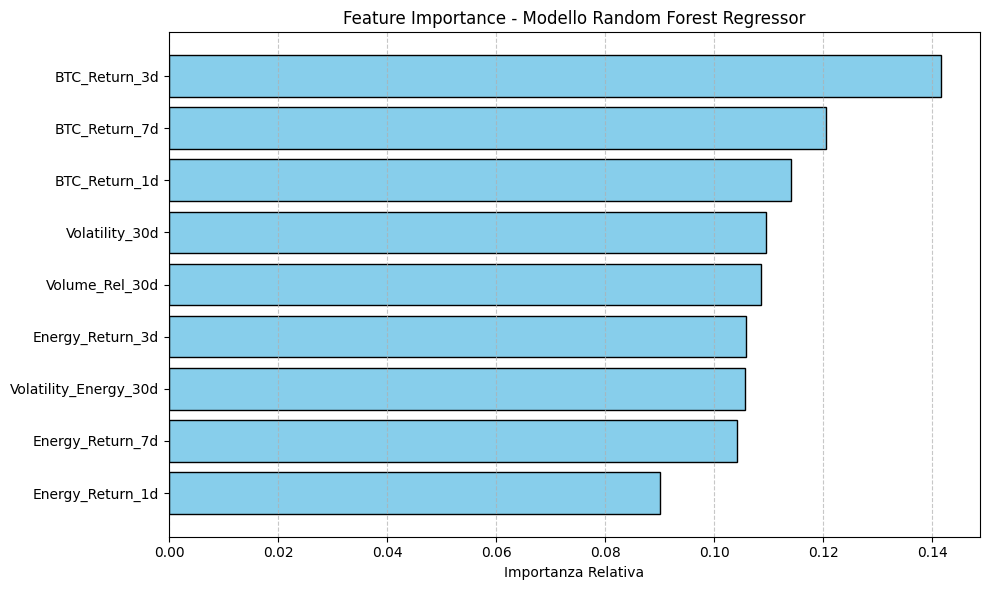

In [16]:
importances = rf_model.feature_importances_
features = X.columns

feature_imp_df = pd.DataFrame({'Feature': features, 'Importanza': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importanza', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importanza'], color='skyblue', edgecolor='black')
plt.xlabel('Importanza Relativa')
plt.title('Feature Importance - Modello Random Forest Regressor')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Il grafico rende chiaro che il modello non è riuscito a ricavare nessuna interazione rilevante: i pesi delle variabili sono tutti simili e nessuna feature emerge come realmente predittiva. Sia i modelli lineari che quelli non lineari falliscono nel prevedere il rendimento del giorno successivo. Dobbiamo quindi **cambiare approccio** se vogliamo estrapolare predizioni valide.

## 5. Ricerca piu approfondita sui dati

Il baseline ha dimostrato che prevedere il rendimento del giorno successivo equivale a prevedere puro rumore (R² < 0): coerente con l'ipotesi di mercato efficiente.

Andiamo quindi ad utilizzare altri modelli validandoli con un simulazione di trading (per quanto imprecisa mancante di slipage e delay dell'eventuale API del broker)

In [17]:
delta = ((df['Price'] - df['Open']) / df['Open']) * 100

def prepare_data(features, target):
    X = pd.DataFrame(features).dropna()
    y = target.reindex_like(X)
    return X, y

def split_temporale(X, y, frac=0.70):
    idx = int(len(X) * frac)
    return X.iloc[:idx], X.iloc[idx:], y.iloc[:idx], y.iloc[idx:]

features = {}
for n in range(1, 4):                      
    features[f'DeltaLag{n}'] = delta.shift(n)
for n in range(1, 4):
    features[f'HighDiff{n}'] = df['High'].pct_change().shift(n) * 100
    features[f'LowDiff{n}']  = df['Low'].pct_change().shift(n) * 100

X, y = prepare_data(features, delta)
X_train, X_test, y_train, y_test = split_temporale(X, y, frac=0.70)

print(f"Feature utilizzate ({X.shape[1]}): {list(X.columns)}")
print(f"Training Set: {len(X_train)} giorni | Test Set: {len(X_test)} giorni")

Feature utilizzate (9): ['DeltaLag1', 'DeltaLag2', 'DeltaLag3', 'HighDiff1', 'LowDiff1', 'HighDiff2', 'LowDiff2', 'HighDiff3', 'LowDiff3']
Training Set: 1225 giorni | Test Set: 525 giorni


### 5.1 Metrica di Valutazione: Simulazione di Trading (ROI)

Oltre all'R² valutiamo i modelli con una **simulazione di trading**:

- se il modello prevede una variazione positiva (Δ > 0, rialzo), si **compra** all'apertura e si rivende alla chiusura, guadagnando Δ
- se prevede una variazione negativa (Δ < 0, ribasso), si **vende allo scoperto**, guadagnando −Δ

Poiché Δ è ora un **rendimento percentuale**, il **Gain** è la somma dei rendimenti per-trade effettivamente realizzati (in punti percentuali) e il **ROI** lo esprime come rendimento su una quota di capitale fissa re-investita a ogni operazione (senza compounding).

Per ROI **non** intendiamo il rendimento del portafoglio complessivo né un valore annualizzato, ma la somma dei rendimenti giornalieri ottenuti re-investendo ogni giorno la stessa singola quota. Un ROI del +14% va quindi inteso come "+14% cumulato su quella quota lungo l'intero periodo di test", non come +14% sul capitale totale impiegato nei vari giorni.

In [18]:
def gain(D, D_pred):
    D_pred = pd.Series(np.asarray(D_pred), index=D.index)
    growth  = D_pred > 0
    decline = D_pred < 0
    return D[growth].sum() - D[decline].sum()

def roi(D, D_pred):
    return gain(D, D_pred) / 100

def print_eval(y_true, y_pred, nome_modello):
    r2 = r2_score(y_true, y_pred)
    print(f"{nome_modello:20} | R²: {r2:+.4f} | Gain: {gain(y_true, y_pred):+8.2f} p.p. | ROI: {roi(y_true, y_pred):+.2%}")

## 6. Confronto dei Modelli

Addestriamo e confrontiamo sei modelli sullo stesso Test Set: i lineari (Linear Regression, Ridge), Random Forest e i tre principali algoritmi di **gradient boosting** (XGBoost, LightGBM, CatBoost). Verifichiamo se almeno uno riesce a ottenere un **R² positivo**, indice di una reale capacità predittiva sulla variazione intraday del Bitcoin.

**Nota sugli iperparametri.** Gli iperparametri di Random Forest e dei modelli di boosting sono fissati su valori ragionevoli (regolarizzazione attiva, *learning rate* basso) ma non ottimizzati tramite grid search.

In [19]:
modelli = {
    "Linear Regression": Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    "Ridge":             Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=1.0))]),
    "Random Forest":     RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost":           XGBRegressor(n_estimators=300, learning_rate=0.03, reg_lambda=1.0,
                                       reg_alpha=0.01, verbosity=0, random_state=42),
    "LightGBM":          LGBMRegressor(n_estimators=300, learning_rate=0.03, reg_lambda=1.0,
                                        reg_alpha=0.01, random_state=42, verbose=-1),
    "CatBoost":          CatBoostRegressor(n_estimators=300, learning_rate=0.03, random_state=42, verbose=False),
}

preds_dict = {}
record_modelli = []
for nome, modello in modelli.items():
    modello.fit(X_train, y_train)
    preds = modello.predict(X_test)
    preds_dict[nome] = preds
    print_eval(y_test, preds, nome)
    record_modelli.append({
        "Modello": nome,
        "R2": round(r2_score(y_test, preds), 4),
        "Gain (p.p.)": round(gain(y_test, preds), 2),
        "ROI": f"{roi(y_test, preds):+.2%}"
    })

print()
df_confronto = pd.DataFrame(record_modelli).sort_values('R2', ascending=False)
display(df_confronto)

Linear Regression    | R²: -0.0022 | Gain:   +28.34 p.p. | ROI: +28.34%
Ridge                | R²: -0.0022 | Gain:   +27.29 p.p. | ROI: +27.29%
Random Forest        | R²: -0.0936 | Gain:   -59.24 p.p. | ROI: -59.24%
XGBoost              | R²: -0.2049 | Gain:   -39.71 p.p. | ROI: -39.71%
LightGBM             | R²: -0.3179 | Gain:   -32.69 p.p. | ROI: -32.69%
CatBoost             | R²: -0.0764 | Gain:   -32.33 p.p. | ROI: -32.33%



,Modello,R2,Gain (p.p.),ROI
0,Linear Regression,-0.0022,28.34,+28.34%
1,Ridge,-0.0022,27.29,+27.29%
5,CatBoost,-0.0764,-32.33,-32.33%
2,Random Forest,-0.0936,-59.24,-59.24%
3,XGBoost,-0.2049,-39.71,-39.71%
4,LightGBM,-0.3179,-32.69,-32.69%


### 6.1 Visualizzazione del Confronto

Rappresentiamo graficamente l'R² ottenuto da ciascun modello: in verde quelli con potere predittivo reale (R² > 0), in rosso quelli con R² negativo, ovvero che predicono **peggio** di una semplice media costante. Come si vede, **tutti i modelli cadono in zona rossa**: nessuno riesce a battere la previsione banale.

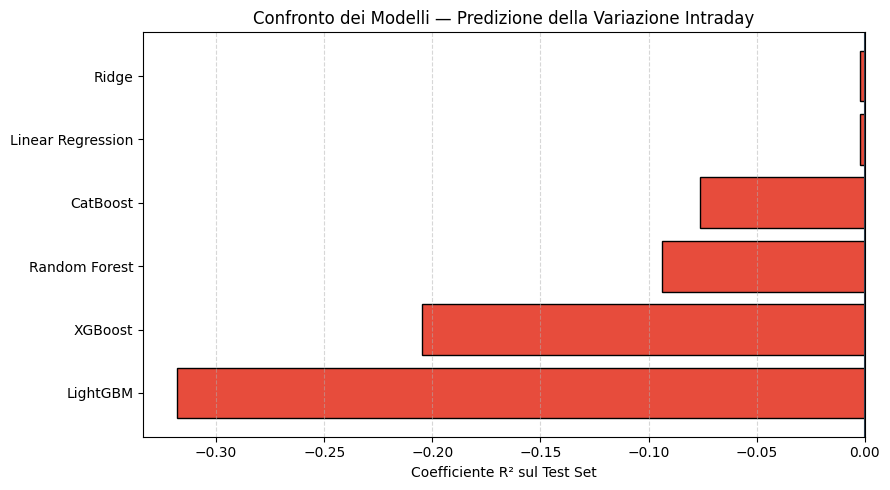

In [20]:
df_plot = df_confronto.sort_values('R2')
colori = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_plot['R2']]

plt.figure(figsize=(9, 5))
plt.barh(df_plot['Modello'], df_plot['R2'], color=colori, edgecolor='black')
plt.axvline(0, color='#2c3e50', linewidth=1.5)
plt.xlabel('Coefficiente R² sul Test Set')
plt.title('Confronto dei Modelli — Predizione della Variazione Intraday')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Validazione Robusta: Cross-Validation Temporale

Il confronto precedente è netto: **nessun modello ottiene un R² positivo**. Un singolo Test Set, però, non basta a chiudere la questione: il ROI calcolato su un unico periodo può risultare positivo o negativo per semplice fortuna, avendo *indovinato il segno* della variazione su quello specifico tratto di mercato, senza alcuna reale capacità predittiva.

Per smascherare questi possibili falsi positivi sottoponiamo **tutti i sei modelli** a una cross-validation temporale con `TimeSeriesSplit(5)`: cinque finestre successive in cui si allena sempre sul passato e si valida sul futuro immediato, usando il **ROI** come metrica. Se un modello catturasse un segnale reale, il suo ROI dovrebbe restare positivo **in modo stabile su tutti i fold**.

In [21]:
roi_scorer = make_scorer(roi, greater_is_better=True)
tscv = TimeSeriesSplit(n_splits=5)

print("Cross-Validation 5-fold — ROI per fold:")
print()
cv_records = []
for nome, modello in modelli.items():
    scores = cross_validate(modello, X, y, cv=tscv, scoring=roi_scorer)['test_score']
    fold_str = '  '.join([f'F{i+1}:{s:+.1%}' for i, s in enumerate(scores)])
    print(f"{nome:20} | ROI medio: {scores.mean():+.2%} | {fold_str}")
    cv_records.append({
        "Modello": nome,
        "ROI medio CV": scores.mean(),
        "ROI min": scores.min(),
        "ROI max": scores.max(),
    })

print()
df_cv = pd.DataFrame(cv_records).sort_values('ROI medio CV', ascending=False)
display(df_cv.style.format({'ROI medio CV': '{:+.2%}', 'ROI min': '{:+.2%}', 'ROI max': '{:+.2%}'}))

Cross-Validation 5-fold — ROI per fold:

Linear Regression    | ROI medio: -10.32% | F1:-22.5%  F2:-63.7%  F3:+9.6%  F4:+37.9%  F5:-13.0%
Ridge                | ROI medio: -10.32% | F1:-22.5%  F2:-63.7%  F3:+9.6%  F4:+37.9%  F5:-13.0%
Random Forest        | ROI medio: -10.20% | F1:-13.5%  F2:+35.6%  F3:-58.5%  F4:+39.7%  F5:-54.3%
XGBoost              | ROI medio: -18.15% | F1:-25.4%  F2:+25.6%  F3:-33.6%  F4:-0.4%  F5:-57.0%
LightGBM             | ROI medio: +5.18% | F1:+63.0%  F2:+59.3%  F3:-2.7%  F4:-39.3%  F5:-54.4%
CatBoost             | ROI medio: -24.33% | F1:-27.5%  F2:-26.1%  F3:-41.0%  F4:+16.8%  F5:-43.8%



,Modello,ROI medio CV,ROI min,ROI max
4,LightGBM,+5.18%,-54.40%,+63.02%
2,Random Forest,-10.20%,-58.48%,+39.66%
1,Ridge,-10.32%,-63.68%,+37.92%
0,Linear Regression,-10.32%,-63.68%,+37.92%
3,XGBoost,-18.15%,-57.01%,+25.63%
5,CatBoost,-24.33%,-43.85%,+16.82%


## 8. Ottimizzazione: Grid Search su Kernel Ridge

Come tentativo finale di estrarre un segnale, proviamo un modello non lineare più flessibile. Tariamo gli iperparametri di un **Kernel Ridge** con kernel RBF tramite grid search, esplorando il parametro di regolarizzazione `alpha` e l'ampiezza del kernel `gamma`. Le feature vengono **sempre standardizzate**: su scala unitaria il kernel RBF si comporta correttamente e la griglia di `gamma` (intorno a 1/n_feature ≈ 0.1) esplora modelli realmente diversi; su feature non scalate il kernel saturerebbe, collassando a predire la media e rendendo il tuning inutile.

**Nota metodologica sullo scoring.** A differenza della valutazione finale, qui *non* usiamo il ROI come metrica di selezione. Il ROI dipende solo dal *segno* delle predizioni e premia chi azzecca la direzione, anche per caso: ottimizzarlo porterebbe a scegliere modelli che fanno overfitting e predicono pessimamente in termini di errore (R² fortemente negativo) ma che, fortuitamente, indovinano abbastanza segni. Per il *tuning* usiamo quindi una metrica d'errore propria, il **Mean Squared Error** (`neg_mean_squared_error`), che misura davvero la qualità delle stime; il ROI resta solo come diagnostica finale, da leggere insieme all'R². La validazione è temporale (`TimeSeriesSplit`) e avviene solo sul training set: il test set viene usato una sola volta.

In [22]:
pipeline_kr = Pipeline([
    ('scale', StandardScaler()),
    ('regr', KernelRidge(kernel='rbf'))
])
grid = {
    'regr__gamma': [0.01, 0.05, 0.1, 0.2, 0.5],
    'regr__alpha': np.logspace(-2, 2, 5)
}

gs = GridSearchCV(pipeline_kr, grid, cv=tscv, scoring='neg_mean_squared_error')
gs.fit(X_train, y_train)

print(f"Migliori parametri:  {gs.best_params_}")
print(f"Miglior MSE (CV su train): {-gs.best_score_:.4f}")
print()

preds_kr = gs.best_estimator_.predict(X_test)
print_eval(y_test, preds_kr, "KernelRidge (tuned)")

gs_results = pd.DataFrame(gs.cv_results_)
display(gs_results.sort_values('mean_test_score', ascending=False)
        [['param_regr__gamma', 'param_regr__alpha', 'mean_test_score']].head(5))

Migliori parametri:  {'regr__alpha': np.float64(100.0), 'regr__gamma': 0.5}
Miglior MSE (CV su train): 7.7861

KernelRidge (tuned)  | R²: -0.0017 | Gain:   -14.02 p.p. | ROI: -14.02%


,param_regr__gamma,param_regr__alpha,mean_test_score
24,0.50,100.0,-7.786078
20,0.01,100.0,-7.789043
23,0.20,100.0,-7.804602
21,0.05,100.0,-7.804738
22,0.10,100.0,-7.808558


## 9. Confronto con un Modello Casuale

Come riferimento finale, confrontiamo i nostri modelli con un **predittore casuale**: 1.000 simulazioni in cui le predizioni sono estratte casualmente dalla stessa distribuzione (media e deviazione standard) dei dati di training. Il ROI medio di un modello casuale tende a circa 0%, perché in media indovina e sbaglia il segno in egual misura.

Per non confondere le due metriche in gioco, mostriamo **entrambi** i criteri di selezione: il modello migliore per **R²** e quello migliore per **ROI**. Il punto cruciale è proprio la dissociazione tra le due: come vedremo, qui il miglior modello ottiene un ROI *superiore* a quello del caso, ma con un **R² negativo**. Un ROI positivo non sostenuto da un R² positivo è infatti indistinguibile dalla fortuna: significa aver azzeccato la *direzione* su questo specifico tratto di test, senza alcuna reale capacità di stimare l'entità del movimento.

l'individuazione del modello migliore per ROI è fatta a posteriori sullo stesso Test Set e ha solo scopo illustrativo serve a evidenziare la dissociazione R²/ROI, non costituisce un criterio di selezione del modello. La selezione effettiva del modello, dove rilevante, avviene sempre su R² o su MSE in cross-validation interna al solo training.

In [23]:
rois_random = []
for s in range(1000):
    np.random.seed(s)
    preds_random = np.random.normal(y_train.mean(), y_train.std(), len(y_test))
    rois_random.append(roi(y_test, preds_random))

roi_medio_random = np.mean(rois_random)

modello_best_r2  = df_confronto.iloc[0]['Modello']
modello_best_roi = max(preds_dict, key=lambda m: roi(y_test, preds_dict[m]))

roi_best_r2  = roi(y_test, preds_dict[modello_best_r2])
roi_best_roi = roi(y_test, preds_dict[modello_best_roi])

print(f"Modello casuale (media 1000 test):        ROI = {roi_medio_random:+.2%}")
print(f"Miglior modello per R²  ({modello_best_r2:<17}): ROI = {roi_best_r2:+.2%}")
print(f"Miglior modello per ROI ({modello_best_roi:<17}): ROI = {roi_best_roi:+.2%}  (ma R² = {r2_score(y_test, preds_dict[modello_best_roi]):+.4f})")
print()
print(f"Vantaggio del miglior modello per R² rispetto al caso: {roi_best_r2 - roi_medio_random:+.2%}")

Modello casuale (media 1000 test):        ROI = +0.17%
Miglior modello per R²  (Linear Regression): ROI = +28.34%
Miglior modello per ROI (Linear Regression): ROI = +28.34%  (ma R² = -0.0022)

Vantaggio del miglior modello per R² rispetto al caso: +28.17%


## 10. Conclusioni e Considerazioni Finali

Questo progetto ha messo a confronto due diverse formulazioni per la costruzione di un modello predittivo sul Bitcoin, tutte con esito negativo.

Per quanto alcuni modelli ottengano ROI positivo il valore del coeficiente di determinazione negativo e prossimo allo zero dimostra quel valore come non significativo. Questo progetto rimane quindi un ulteriore evidenza empirica sull'efficienza dei mercati finanziari. Considerando anche la natura di comodity estremamente volative e dal valore intrinseco difficilmente stimabile del mercato scelto il risultato finale non è sorprendente. Ciononostante mi ritengo personalmente soddisfatto del progetto.